# 05 - Correlation Cluster Tuning

## Purpose of this notebook

In this notebook, I build a data-driven grouping approach for the ETF universe using the correlation matrix from the train period.

Instead of manually deciding which ETFs belong together, I use historical return behavior to learn groups of similar assets. Then I test whether assigning one momentum lookback window per learned cluster improves the tactical ETF strategy.

## Why this notebook matters

The previous notebook used manually defined asset classes:
- equities
- defensive / macro

That approach is economically intuitive, but it may not be the grouping that best reflects actual ETF behavior in the data.

This notebook asks whether a correlation-based clustering approach can create better groups and produce better risk-adjusted portfolio performance.

## Main research question

Can data-driven cluster-level tuning outperform:
- the shared baseline model
- the manual asset-class-tuned model

while still being more disciplined than full ETF-level tuning?

## 2. Import libraries

In this section, I import the libraries needed for:
- data handling
- plotting
- clustering
- distance calculations
- backtesting

## What this section is doing

I use:
- `pandas` and `numpy` for data work
- `matplotlib` for plots
- `scipy` for hierarchical clustering and distance tools
- `pathlib` for file paths

## What I can change later

- I can use seaborn later for cleaner heatmaps
- I can move stable helper functions into `src/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Load processed data and earlier model outputs

In this section, I load:
- monthly returns
- monthly moving average filter
- monthly rolling volatility
- monthly momentum tables
- shared baseline returns
- best manual asset-class-tuned returns

## Why this matters

I need the signal tables for the new cluster-tuned backtest, and I also want earlier model outputs available so I can compare performance directly.

In [2]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

monthly_returns = pd.read_csv(PROCESSED_DIR / "monthly_returns.csv", index_col=0, parse_dates=True)
ma_filter_monthly = pd.read_csv(PROCESSED_DIR / "ma_filter_monthly.csv", index_col=0, parse_dates=True)
rolling_vol_monthly = pd.read_csv(PROCESSED_DIR / "rolling_vol_monthly.csv", index_col=0, parse_dates=True)

momentum_tables = {
    60: pd.read_csv(PROCESSED_DIR / "momentum_60d_monthly.csv", index_col=0, parse_dates=True),
    120: pd.read_csv(PROCESSED_DIR / "momentum_120d_monthly.csv", index_col=0, parse_dates=True),
    180: pd.read_csv(PROCESSED_DIR / "momentum_180d_monthly.csv", index_col=0, parse_dates=True),
    252: pd.read_csv(PROCESSED_DIR / "momentum_252d_monthly.csv", index_col=0, parse_dates=True),
}

shared_baseline_returns = pd.read_csv(PROCESSED_DIR / "strategy_returns_shared_baseline.csv", index_col=0, parse_dates=True)
best_asset_class_returns = pd.read_csv(PROCESSED_DIR / "best_asset_class_returns.csv", index_col=0, parse_dates=True)

print("Monthly returns shape:", monthly_returns.shape)
print("MA filter shape:", ma_filter_monthly.shape)
print("Rolling vol shape:", rolling_vol_monthly.shape)
print("Shared baseline returns shape:", shared_baseline_returns.shape)
print("Best asset-class returns shape:", best_asset_class_returns.shape)

Monthly returns shape: (253, 8)
MA filter shape: (242, 8)
Rolling vol shape: (242, 8)
Shared baseline returns shape: (242, 4)
Best asset-class returns shape: (242, 1)


## 4. Define research split and backtest settings

In this section, I define:
- the train / validation / test periods
- the top-K rule
- the fallback asset
- the tested momentum windows
- the number of clusters

## Why this matters

The clustering must be learned from the train set only, and the same split framework must be used consistently throughout the project.

In [3]:
TRAIN_START = "2005-01-01"
TRAIN_END = "2014-12-31"

VALID_START = "2015-01-01"
VALID_END = "2018-12-31"

TEST_START = "2019-01-01"
TEST_END = monthly_returns.index.max().strftime("%Y-%m-%d")

TOP_K = 2
FALLBACK_ASSET = "IEF"
MOMENTUM_WINDOWS = [60, 120, 180, 252]
N_CLUSTERS = 2

print("Top K:", TOP_K)
print("Fallback asset:", FALLBACK_ASSET)
print("Momentum windows:", MOMENTUM_WINDOWS)
print("Number of clusters:", N_CLUSTERS)

Top K: 2
Fallback asset: IEF
Momentum windows: [60, 120, 180, 252]
Number of clusters: 2


## 5. Align all inputs to a common monthly index

In this section, I make sure that monthly returns and all signal tables use the same dates.

## Why this matters

This avoids mismatches when I combine cluster-level momentum tables with the portfolio construction rules.

In [4]:
common_index = monthly_returns.index.intersection(ma_filter_monthly.index).intersection(rolling_vol_monthly.index)
for window in MOMENTUM_WINDOWS:
    common_index = common_index.intersection(momentum_tables[window].index)

common_index = common_index.sort_values()

monthly_returns = monthly_returns.loc[common_index]
ma_filter_monthly = ma_filter_monthly.loc[common_index]
rolling_vol_monthly = rolling_vol_monthly.loc[common_index]
for window in MOMENTUM_WINDOWS:
    momentum_tables[window] = momentum_tables[window].loc[common_index]

print("Common monthly observations:", len(common_index))
print("First date:", common_index.min())
print("Last date:", common_index.max())

Common monthly observations: 242
First date: 2006-01-31 00:00:00
Last date: 2026-02-27 00:00:00


## 6. Restrict clustering to the train period

In this section, I isolate the train-period monthly returns.

## What this section is doing

I only use the train data to learn the ETF clusters. This avoids using future information when defining the groups.

## Why this matters

If I used validation or test data to form the clusters, the grouping itself would become forward-looking.

In [5]:
train_returns = monthly_returns.loc[TRAIN_START:TRAIN_END].copy()

print("Train return observations:", len(train_returns))
display(train_returns.head())

Train return observations: 108


,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
2006-01-31,0.141983,0.057715,0.099263,-0.007030,0.084383,0.039347,0.024014,-0.013385
2006-02-28,-0.038500,-0.007000,-0.011111,-0.001036,0.003178,-0.021429,0.005726,0.011080
2006-03-31,0.021672,0.040051,0.036205,-0.013578,0.049089,0.020911,0.016503,-0.045700
2006-04-28,0.065152,0.047905,0.120310,-0.006272,0.003027,-0.001909,0.012632,-0.027524
2006-05-31,-0.111427,-0.038219,-0.013212,-0.001068,-0.056824,-0.072401,-0.030121,-0.001908


## 7. Compute the train-period correlation matrix

In this section, I compute the ETF correlation matrix using only train-period monthly returns.

## What this section is doing

The correlation matrix summarizes how similarly the ETFs moved during the train period.

## Why this matters

This is the core input for the clustering step. Assets that move similarly should tend to appear in the same cluster.

## What I can change later

- I can later compare train-period daily correlation vs monthly correlation
- I can later use rolling correlations or feature-based clustering

In [6]:
corr_train = train_returns.corr()
corr_train

,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
EEM,1.000000,0.897294,0.311852,-0.208017,0.786515,0.788112,0.821907,-0.269825
EFA,0.897294,1.000000,0.201225,-0.202720,0.824228,0.806104,0.904921,-0.249804
GLD,0.311852,0.201225,1.000000,0.239681,0.106756,0.058151,0.092926,0.101759
IEF,-0.208017,-0.202720,0.239681,1.000000,-0.335830,-0.310053,-0.277474,0.892808
IWM,0.786515,0.824228,0.106756,-0.335830,1.000000,0.858252,0.920287,-0.359070
QQQ,0.788112,0.806104,0.058151,-0.310053,0.858252,1.000000,0.903753,-0.346385
SPY,0.821907,0.904921,0.092926,-0.277474,0.920287,0.903753,1.000000,-0.317175
TLT,-0.269825,-0.249804,0.101759,0.892808,-0.359070,-0.346385,-0.317175,1.000000


## 8. Convert correlation to a distance matrix

In this section, I convert the correlation matrix into a distance matrix.

## What this section is doing

I use the transformation:

d(i, j) = sqrt(2 * (1 - corr(i, j)))

This turns high correlation into small distance and low correlation into larger distance.

## Why this matters

Hierarchical clustering works with distances, not correlations directly.

In [7]:
distance_matrix = np.sqrt(2 * (1 - corr_train))

# numerical cleanup
distance_matrix = distance_matrix.clip(lower=0)

distance_matrix

,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
EEM,0.000000,0.453225,1.173156,1.554360,0.653430,0.650980,0.596814,1.593628
EFA,0.453225,0.000000,1.263942,1.550948,0.592911,0.622730,0.436072,1.581015
GLD,1.173156,1.263942,0.000000,1.233141,1.336596,1.372479,1.346903,1.340329
IEF,1.554360,1.550948,1.233141,0.000000,1.634521,1.618674,1.598420,0.463016
IWM,0.653430,0.592911,1.336596,1.634521,0.000000,0.532443,0.399281,1.648678
QQQ,0.650980,0.622730,1.372479,1.618674,0.532443,0.000000,0.438741,1.640966
SPY,0.596814,0.436072,1.346903,1.598420,0.399281,0.438741,0.000000,1.623068
TLT,1.593628,1.581015,1.340329,0.463016,1.648678,1.640966,1.623068,0.000000


## 9. Perform hierarchical clustering

In this section, I cluster the ETFs using the correlation-based distance matrix.

## What this section is doing

I use hierarchical clustering with the train-period ETF distances, then assign each ETF to one of a fixed number of clusters.

## Why this matters

This gives me data-driven groups that can later share momentum parameters.

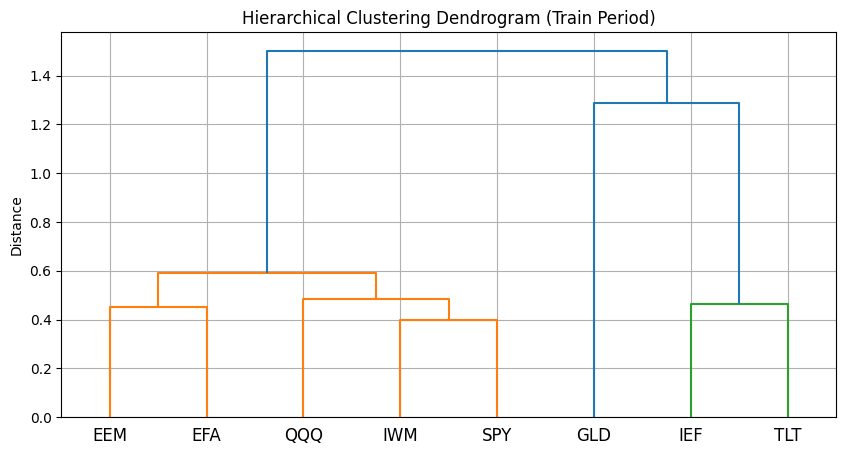

In [8]:
# linkage requires condensed distance form
condensed_distance = squareform(distance_matrix.values, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=distance_matrix.index.tolist())
plt.title("Hierarchical Clustering Dendrogram (Train Period)")
plt.ylabel("Distance")
plt.show()

In [9]:
cluster_labels = fcluster(linkage_matrix, t=N_CLUSTERS, criterion="maxclust")

cluster_map = pd.Series(cluster_labels, index=distance_matrix.index, name="Cluster").sort_values()
cluster_map

EEM    1
EFA    1
IWM    1
QQQ    1
SPY    1
GLD    2
IEF    2
TLT    2
Name: Cluster, dtype: int32

## 10. Inspect the learned ETF clusters

In this section, I inspect which ETFs were assigned to each cluster.

## Why this matters

Before tuning anything, I want to check whether the learned groups are intuitive and whether they differ meaningfully from the manual asset classes.

In [10]:
clusters = {}
for cluster_id in sorted(cluster_map.unique()):
    clusters[cluster_id] = cluster_map[cluster_map == cluster_id].index.tolist()

clusters

{np.int32(1): ['EEM', 'EFA', 'IWM', 'QQQ', 'SPY'],
 np.int32(2): ['GLD', 'IEF', 'TLT']}

## 11. Helper functions

In this section, I define helper functions for:
- inverse-volatility weighting
- performance metrics
- split metrics
- building mixed momentum tables using learned clusters

In [11]:
def inverse_vol_weights(vol_series):
    vol_series = vol_series.replace(0, np.nan).dropna()
    if len(vol_series) == 0:
        return pd.Series(dtype=float)
    inv_vol = 1 / vol_series
    return inv_vol / inv_vol.sum()


def compute_metrics(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return {}

    cumulative = (1 + return_series).cumprod()
    total_months = len(return_series)

    cagr = cumulative.iloc[-1] ** (12 / total_months) - 1
    ann_vol = return_series.std() * np.sqrt(12)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


def compute_split_metrics(return_series, train_start, train_end, valid_start, valid_end, test_start, test_end):
    train = return_series.loc[train_start:train_end]
    valid = return_series.loc[valid_start:valid_end]
    test = return_series.loc[test_start:test_end]

    train_metrics = compute_metrics(train)
    valid_metrics = compute_metrics(valid)
    test_metrics = compute_metrics(test)

    return {
        "Train Sharpe": train_metrics.get("Sharpe"),
        "Valid Sharpe": valid_metrics.get("Sharpe"),
        "Test Sharpe": test_metrics.get("Sharpe"),
        "Train CAGR": train_metrics.get("CAGR"),
        "Valid CAGR": valid_metrics.get("CAGR"),
        "Test CAGR": test_metrics.get("CAGR"),
        "Train MaxDD": train_metrics.get("Max Drawdown"),
        "Valid MaxDD": valid_metrics.get("Max Drawdown"),
        "Test MaxDD": test_metrics.get("Max Drawdown"),
    }


def generate_weight_table(momentum_df, ma_filter_df, vol_df, top_k=2, fallback_asset="IEF"):
    assets = momentum_df.columns.tolist()
    weight_records = []

    for dt in momentum_df.index:
        momentum_today = momentum_df.loc[dt]
        ma_today = ma_filter_df.loc[dt]
        vol_today = vol_df.loc[dt]

        weights = pd.Series(0.0, index=assets)

        eligible = momentum_today[ma_today].dropna().sort_values(ascending=False)
        selected_assets = eligible.head(top_k).index.tolist()

        if len(selected_assets) > 0:
            selected_vol = vol_today.loc[selected_assets].dropna()
            selected_weights = inverse_vol_weights(selected_vol)

            for asset, w in selected_weights.items():
                weights[asset] = w

        weight_sum = weights.sum()

        if weight_sum < 1.0:
            weights[fallback_asset] += (1.0 - weight_sum)

        weight_records.append(weights)

    return pd.DataFrame(weight_records, index=momentum_df.index)

## 12. Build mixed momentum tables using learned clusters

In this section, I create a combined momentum table where each learned cluster uses its own momentum lookback window.

## Why this matters

This is the core portfolio idea of this notebook.

In [12]:
def build_cluster_momentum_table(cluster_window_map, cluster_map, momentum_tables):
    parts = []

    for cluster_id, window in cluster_window_map.items():
        assets = cluster_map[cluster_map == cluster_id].index.tolist()
        part = momentum_tables[window][assets]
        parts.append(part)

    combined = pd.concat(parts, axis=1)
    combined = combined[cluster_map.index.tolist()]  # preserve original asset order
    return combined

## 13. Grid search across cluster-level momentum combinations

In this section, I test all momentum-window combinations across the learned clusters.

## What this section is doing

If there are 2 clusters and 4 candidate windows, then I test 4 x 4 = 16 cluster-window combinations.

For each combination, I:
- build the mixed momentum table
- construct weights
- shift weights by one month
- compute realized returns
- measure performance across train, validation, and test

In [13]:
cluster_ids = sorted(cluster_map.unique())

results = {}
metrics_rows = []

# supports 2 clusters cleanly; still works generally with product-like nested loops later if expanded
for window_1 in MOMENTUM_WINDOWS:
    for window_2 in MOMENTUM_WINDOWS:
        cluster_window_map = {
            cluster_ids[0]: window_1,
            cluster_ids[1]: window_2,
        }

        label = f"CL{cluster_ids[0]}_{window_1}_CL{cluster_ids[1]}_{window_2}"

        mixed_momentum = build_cluster_momentum_table(
            cluster_window_map=cluster_window_map,
            cluster_map=cluster_map,
            momentum_tables=momentum_tables,
        )

        weights = generate_weight_table(
            momentum_df=mixed_momentum,
            ma_filter_df=ma_filter_monthly[mixed_momentum.columns],
            vol_df=rolling_vol_monthly[mixed_momentum.columns],
            top_k=TOP_K,
            fallback_asset=FALLBACK_ASSET,
        )

        shifted_weights = weights.shift(1)
        returns = (shifted_weights * monthly_returns[mixed_momentum.columns]).sum(axis=1, min_count=1)

        results[label] = {
            "cluster_window_map": cluster_window_map,
            "weights": weights,
            "shifted_weights": shifted_weights,
            "returns": returns,
        }

        full_metrics = compute_metrics(returns)
        split_metrics = compute_split_metrics(
            returns,
            TRAIN_START, TRAIN_END,
            VALID_START, VALID_END,
            TEST_START, TEST_END
        )

        row = {
            "Model": label,
            f"Cluster_{cluster_ids[0]}_Window": window_1,
            f"Cluster_{cluster_ids[1]}_Window": window_2,
            **full_metrics,
            **split_metrics,
        }
        metrics_rows.append(row)

cluster_metrics = pd.DataFrame(metrics_rows).set_index("Model")
cluster_metrics.head()

,Cluster_1_Window,Cluster_2_Window,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar,Train Sharpe,Valid Sharpe,Test Sharpe,Train CAGR,Valid CAGR,Test CAGR,Train MaxDD,Valid MaxDD,Test MaxDD
Model,,,,,,,,,,,,,,,,
CL1_60_CL2_60,60,60,0.123161,0.126813,0.971206,-0.230909,0.533378,1.182983,0.311848,1.044502,0.152080,0.033659,0.139817,-0.150569,-0.202726,-0.230909
CL1_60_CL2_120,60,120,0.119738,0.123893,0.966466,-0.230909,0.518553,1.126174,0.279746,1.131494,0.149025,0.030821,0.135589,-0.107750,-0.218156,-0.230909
CL1_60_CL2_180,60,180,0.121874,0.123317,0.988295,-0.237475,0.513207,1.306640,0.133353,1.069273,0.165288,0.015239,0.131457,-0.090882,-0.224864,-0.237475
CL1_60_CL2_252,60,252,0.120764,0.122589,0.985113,-0.227819,0.530088,1.246892,0.165652,1.066162,0.158542,0.016434,0.135758,-0.097064,-0.198619,-0.227819
CL1_120_CL2_60,120,60,0.108613,0.126912,0.855816,-0.244820,0.443646,1.129764,0.501997,0.709065,0.144377,0.057571,0.094081,-0.167763,-0.190997,-0.244820


## 14. Rank the cluster-tuned models

In this section, I rank the tested cluster-tuned models using validation and test quality.

## Why this matters

I want to identify whether the learned-cluster approach produces a stronger candidate than the earlier models.

In [15]:
ranked_cluster_models = cluster_metrics.sort_values(
    ["Valid Sharpe", "Test Sharpe", "Valid CAGR", "Test CAGR"],
    ascending=False
)

ranked_cluster_models.head(10)

,Cluster_1_Window,Cluster_2_Window,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar,Train Sharpe,Valid Sharpe,Test Sharpe,Train CAGR,Valid CAGR,Test CAGR,Train MaxDD,Valid MaxDD,Test MaxDD
Model,,,,,,,,,,,,,,,,
CL1_180_CL2_180,180,180,0.114866,0.121534,0.945130,-0.238701,0.481210,0.866930,0.617893,1.225022,0.108669,0.071566,0.147721,-0.115345,-0.143657,-0.238701
CL1_120_CL2_120,120,120,0.124122,0.128584,0.965302,-0.244820,0.506995,1.132896,0.613173,0.928628,0.154989,0.069800,0.117333,-0.157982,-0.171450,-0.244820
CL1_180_CL2_252,180,252,0.134585,0.120706,1.114986,-0.225921,0.595717,1.167242,0.574130,1.335699,0.143845,0.063494,0.164473,-0.108815,-0.133160,-0.225921
CL1_252_CL2_120,252,120,0.092142,0.123508,0.746036,-0.225921,0.407850,0.842570,0.520606,0.733146,0.107638,0.054367,0.094456,-0.215244,-0.124227,-0.225921
CL1_120_CL2_60,120,60,0.108613,0.126912,0.855816,-0.244820,0.443646,1.129764,0.501997,0.709065,0.144377,0.057571,0.094081,-0.167763,-0.190997,-0.244820
CL1_180_CL2_120,180,120,0.105638,0.122710,0.860877,-0.225921,0.467589,0.793915,0.485991,1.159795,0.104580,0.053478,0.137220,-0.163500,-0.130421,-0.225921
CL1_252_CL2_60,252,60,0.087071,0.130554,0.666938,-0.304280,0.286155,0.536096,0.418871,0.958823,0.074834,0.041638,0.129077,-0.304280,-0.132523,-0.225921
CL1_180_CL2_60,180,60,0.077149,0.128857,0.598717,-0.290765,0.265331,0.560080,0.397194,0.748782,0.076726,0.043548,0.096907,-0.290765,-0.138659,-0.228047
CL1_252_CL2_180,252,180,0.107415,0.126918,0.846338,-0.240328,0.446952,0.852548,0.380507,1.074131,0.110502,0.042682,0.141318,-0.240328,-0.137374,-0.225921


In [16]:
best_cluster_model = ranked_cluster_models.index[0]
best_cluster_returns = results[best_cluster_model]["returns"]
best_cluster_weights = results[best_cluster_model]["shifted_weights"]

best_cluster_model, ranked_cluster_models.loc[best_cluster_model]

('CL1_180_CL2_180',
 Cluster_1_Window    180.000000
 Cluster_2_Window    180.000000
 CAGR                  0.114866
 Annual Vol            0.121534
 Sharpe                0.945130
 Max Drawdown         -0.238701
 Calmar                0.481210
 Train Sharpe          0.866930
 Valid Sharpe          0.617893
 Test Sharpe           1.225022
 Train CAGR            0.108669
 Valid CAGR            0.071566
 Test CAGR             0.147721
 Train MaxDD          -0.115345
 Valid MaxDD          -0.143657
 Test MaxDD           -0.238701
 Name: CL1_180_CL2_180, dtype: float64)

## 15. Compare the best cluster-tuned model against earlier models

In this section, I compare the best cluster-tuned model against:
- the shared baseline strategies
- the best manual asset-class model

## Why this matters

The cluster-tuned model only deserves to continue if it actually improves over simpler approaches.

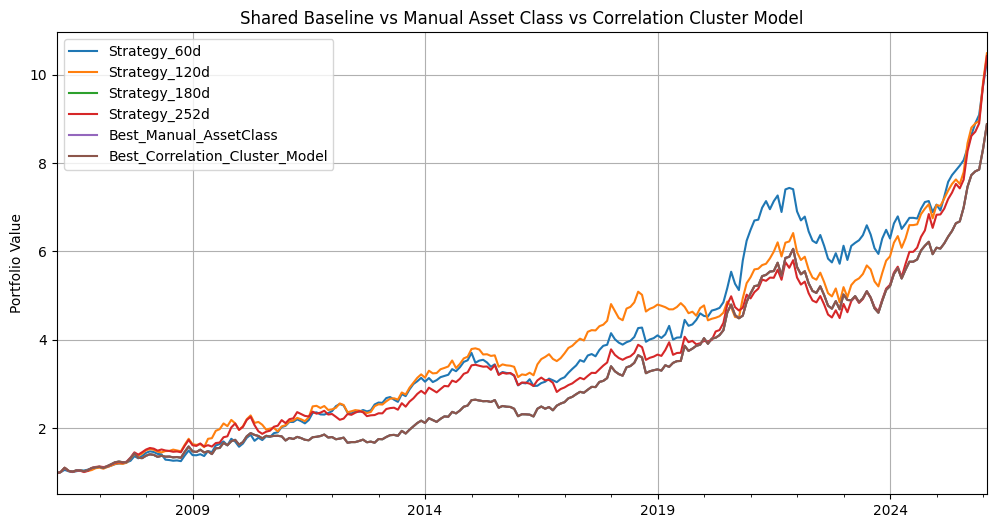

In [17]:
comparison_returns = pd.concat(
    [
        shared_baseline_returns,
        best_asset_class_returns.rename(columns={best_asset_class_returns.columns[0]: "Best_Manual_AssetClass"}),
        best_cluster_returns.rename("Best_Correlation_Cluster_Model"),
    ],
    axis=1
).dropna()

comparison_cumulative = (1 + comparison_returns).cumprod()
comparison_cumulative.plot(title="Shared Baseline vs Manual Asset Class vs Correlation Cluster Model")
plt.ylabel("Portfolio Value")
plt.show()

## 16. Visualize validation Sharpe across the cluster grid

In this section, I inspect whether cluster-tuning performance looks stable or fragile across the tested window pairs.

In [18]:
validation_sharpe_grid = cluster_metrics.pivot(
    index=f"Cluster_{cluster_ids[0]}_Window",
    columns=f"Cluster_{cluster_ids[1]}_Window",
    values="Valid Sharpe"
)

validation_sharpe_grid

Cluster_2_Window,60,120,180,252
Cluster_1_Window,,,,
60,0.311848,0.279746,0.133353,0.165652
120,0.501997,0.613173,0.324126,0.134246
180,0.397194,0.485991,0.617893,0.574130
252,0.418871,0.520606,0.380507,0.243556


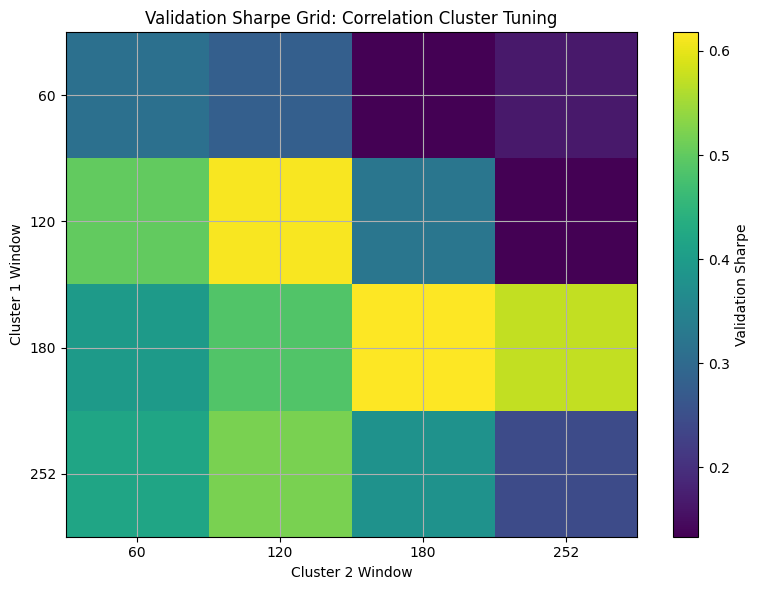

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(validation_sharpe_grid, aspect="auto")
plt.colorbar(label="Validation Sharpe")
plt.xticks(range(len(validation_sharpe_grid.columns)), validation_sharpe_grid.columns)
plt.yticks(range(len(validation_sharpe_grid.index)), validation_sharpe_grid.index)
plt.xlabel(f"Cluster {cluster_ids[1]} Window")
plt.ylabel(f"Cluster {cluster_ids[0]} Window")
plt.title("Validation Sharpe Grid: Correlation Cluster Tuning")
plt.tight_layout()
plt.show()

## 17. Inspect the best model's weights and cluster assignment

In this section, I inspect:
- the learned ETF cluster assignments
- the best model's shifted weights

This helps verify that the results are interpretable and sensible.

In [20]:
print("Learned cluster assignments:")
display(cluster_map.sort_values())

best_weights_check = best_cluster_weights.copy()
best_weights_check["WeightSum"] = best_weights_check.sum(axis=1)
display(best_weights_check.head(12))

Learned cluster assignments:


EEM    1
EFA    1
IWM    1
QQQ    1
SPY    1
GLD    2
IEF    2
TLT    2
Name: Cluster, dtype: int32

,EEM,EFA,IWM,QQQ,SPY,GLD,IEF,TLT,WeightSum
2006-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2006-02-28,0.499743,0.000000,0.0,0.0,0.0,0.500257,0.0,0.0,1.0
2006-03-31,0.489035,0.000000,0.0,0.0,0.0,0.510965,0.0,0.0,1.0
2006-04-28,0.455195,0.000000,0.0,0.0,0.0,0.544805,0.0,0.0,1.0
2006-05-31,0.507230,0.000000,0.0,0.0,0.0,0.492770,0.0,0.0,1.0
2006-06-30,0.000000,0.644127,0.0,0.0,0.0,0.355873,0.0,0.0,1.0
2006-07-31,0.480489,0.000000,0.0,0.0,0.0,0.519511,0.0,0.0,1.0
2006-08-31,0.424610,0.000000,0.0,0.0,0.0,0.575390,0.0,0.0,1.0
2006-09-29,0.000000,0.573737,0.0,0.0,0.0,0.426263,0.0,0.0,1.0
2006-10-31,0.000000,0.612108,0.0,0.0,0.0,0.387892,0.0,0.0,1.0


## 18. Save cluster-tuning outputs

In this section, I save the key outputs from the correlation-cluster-tuning experiment.

In [21]:
cluster_metrics.to_csv(PROCESSED_DIR / "correlation_cluster_tuning_metrics.csv")
ranked_cluster_models.to_csv(PROCESSED_DIR / "correlation_cluster_tuning_ranked.csv")
best_cluster_returns.to_csv(PROCESSED_DIR / "best_correlation_cluster_returns.csv")
best_cluster_weights.to_csv(PROCESSED_DIR / "best_correlation_cluster_weights.csv")
cluster_map.to_csv(PROCESSED_DIR / "correlation_cluster_map.csv")

print("Saved correlation-cluster-tuning outputs to:", PROCESSED_DIR.resolve())

Saved correlation-cluster-tuning outputs to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed


## 19. Key takeaways from this notebook

At this stage, I have tested a data-driven grouping approach using the train-period correlation matrix.

## What I accomplished

- learned ETF groups from the train-period correlation structure
- assigned one momentum window per learned cluster
- backtested all tested cluster-window combinations
- evaluated performance across train, validation, and test
- compared the best cluster-tuned model against the earlier baselines

## What I learned

This notebook helps answer whether data-driven grouping provides a stronger middle ground between simple shared parameters and fully customized ETF-level tuning.

## What comes next

The next model family is the most flexible one:
- ETF-level tuning

That notebook will test whether giving each ETF its own momentum window actually produces enough improvement to justify the added complexity and overfitting risk.